# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT1",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


You can now save your data files in: /home/runner/work/Machine-Learning/Machine-Learning/36106/assignment/AT1/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.
sh: 1: import: not found
sh: 1: Syntax error: word unexpected (expecting ")")


---
## Student Information

In [2]:
# <Student to fill this section and then remove this comment>
student_name = "Aryan Goel"
student_id = "26040826"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### 0.b Import Packages

In [6]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

---
## A. Experiment Description

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "1"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [8]:
experiment_hypothesis = """
Hypothesis:
Multivariate Linear Regression will outperform the constant mean baseline
by leveraging engineered vehicle features (age, kilometres, brand tier,
engine capacity, etc.) to learn a linear price function. While a linear
model cannot capture non-linear interactions, it should still explain a
meaningful portion of price variance and reduce MAE significantly below the
baseline's ~$19,000–$20,000.
"""


In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [10]:
experiment_expectations = """
Expected outcome:
- LinearRegression with fit_intercept=True should achieve a Validation MAE
  between $10,000 and $14,000 (roughly 30–50% lower than the mean baseline).
- Validation R² expected between 0.45 and 0.65, indicating the linear model
  captures a substantial portion of price variance.
- Validation RMSE expected between $18,000 and $26,000.
- fit_intercept=True should outperform fit_intercept=False because vehicle
  prices have a non-zero intercept (even with zero features, base prices exist).
- The model should show minimal overfitting (train vs val MAE gap < $1,000)
  because a linear model has low complexity.
"""


In [11]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## B. Feature Selection


In [12]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [13]:
features_list = X_train.columns.tolist()

print("Number of selected features:", len(features_list))
print("First 20 selected features:", features_list[:20])


Number of selected features: 25
First 20 selected features: ['vehicle_brand', 'model_name', 'manufacturing_year', 'kilometres_driven', 'vehicle_condition', 'vehicle_type', 'body_type', 'engine_capacity', 'engine_cylinders', 'transmission_type', 'drive_type', 'fuel_type', 'fuel_consumption', 'doors', 'seats', 'location', 'state', 'vehicle_age', 'km_per_year', 'desc_len']


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("EXPERIMENT 1: FEATURE SELECTION + PREPROCESSING (stratified resplit)")
print("=" * 72)

# ---- 0) Pool all data from provided splits ----
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

y_train_raw = y_train.values.ravel().astype(float)
y_val_raw   = y_val.values.ravel().astype(float)
y_test_raw  = y_test.values.ravel().astype(float)

X_all = pd.concat([X_train_raw, X_val_raw, X_test_raw], ignore_index=True)
y_all = np.concatenate([y_train_raw, y_val_raw, y_test_raw])

# ---- 1) Drop NaN targets (CRITICAL) ----
mask = ~np.isnan(y_all)
X_all = X_all.loc[mask].reset_index(drop=True)
y_all = y_all[mask].astype(float)

# ---- 2) Basic target sanity filters (optional, but keeps RMSE stable) ----
# Keep only reasonable prices (you already used >=500; keep same)
price_mask = y_all >= 500
X_all = X_all.loc[price_mask].reset_index(drop=True)
y_all = y_all[price_mask]

print(f"After cleaning: {len(y_all):,} rows")
print(f"Price range: ${y_all.min():,.0f} - ${y_all.max():,.0f}")

# ---- 3) Stratified resplit on price quantiles ----
price_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

X_temp, X_test_new, y_temp, y_test_new = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=price_bins
)

price_bins_temp = pd.qcut(y_temp, q=10, labels=False, duplicates="drop")

X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=price_bins_temp
)

print("\nStratified split sizes:")
print(f"  Train: {len(y_train_new):,} | Val: {len(y_val_new):,} | Test: {len(y_test_new):,}")
for name, y_ in [("train", y_train_new), ("val", y_val_new), ("test", y_test_new)]:
    print(f"  {name}: mean=${y_.mean():,.0f}  median=${np.median(y_):,.0f}  p95=${np.percentile(y_,95):,.0f}")

# ---- 4) Clean / cap categoricals (must be fit on TRAIN only) ----
valid_vehicle_types = {
    "suv", "hatchback", "sedan", "ute / tray", "ute/tray",
    "wagon", "commercial", "coupe", "convertible",
    "people mover", "van", "truck", "bus", "cab chassis",
    "minivan", "mpv", "4wd", "crossover"
}

def clean_vehicle_type(series):
    s = series.astype(str).str.strip().str.lower()
    return s.apply(lambda x: x if x in valid_vehicle_types else "other")

def cap_top_n(train_col, col, n=20, fill="other"):
    top_n = train_col.astype(str).str.strip().str.lower().value_counts().nlargest(n).index
    return col.astype(str).str.strip().str.lower().apply(lambda x: x if x in top_n else fill)

X_tr = X_train_new.copy()
X_va = X_val_new.copy()
X_te = X_test_new.copy()

for df in [X_tr, X_va, X_te]:
    # normalize all object cols
    for c in df.select_dtypes(include=["object"]).columns:
        df[c] = df[c].astype(str).str.strip().str.lower()
    # clean vehicle_type if present
    if "vehicle_type" in df.columns:
        df["vehicle_type"] = clean_vehicle_type(df["vehicle_type"])

# cap model_name based on TRAIN only (if present)
if "model_name" in X_tr.columns:
    X_tr["model_name"] = cap_top_n(X_tr["model_name"], X_tr["model_name"], n=20)
    X_va["model_name"] = cap_top_n(X_tr["model_name"], X_va["model_name"], n=20)
    X_te["model_name"] = cap_top_n(X_tr["model_name"], X_te["model_name"], n=20)

# Example: drop columns you don't want (keep consistent)
drop_cols = []
for c in ["location", "manufacturing_year"]:
    if c in X_tr.columns:
        drop_cols.append(c)

for df in [X_tr, X_va, X_te]:
    df.drop(columns=drop_cols, inplace=True, errors="ignore")

# ---- 5) One-hot encode + align ----
X_train_enc = pd.get_dummies(X_tr, drop_first=False)
X_val_enc   = pd.get_dummies(X_va, drop_first=False)
X_test_enc  = pd.get_dummies(X_te, drop_first=False)

X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# ---- 6) Scale (Linear Regression benefits from scaling) ----
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_enc), columns=X_train_enc.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_enc), columns=X_train_enc.columns)

X_train_selected = X_train_scaled
X_val_selected   = X_val_scaled
X_test_selected  = X_test_scaled

# Targets (already NaN-clean)
ytr_raw = y_train_new.astype(float)
yva_raw = y_val_new.astype(float)
yte_raw = y_test_new.astype(float)

features_list = X_train_selected.columns.tolist()

print(f"\nFinal encoded shape: {X_train_selected.shape}")
print(f"Feature list preview (first 20): {features_list[:20]}")
print("\n✅ Section B complete.")

EXPERIMENT 1: FEATURE SELECTION + PREPROCESSING (stratified resplit)
After cleaning: 13,986 rows
Price range: $900 - $1,500,000

Stratified split sizes:
  Train: 8,391 | Val: 2,797 | Test: 2,798
  train: mean=$36,436  median=$27,878  p95=$86,888
  val: mean=$36,074  median=$27,880  p95=$84,820
  test: mean=$35,916  median=$27,856  p95=$87,065



Final encoded shape: (8391, 142)
Feature list preview (first 20): ['kilometres_driven', 'engine_capacity', 'engine_cylinders', 'fuel_consumption', 'doors', 'seats', 'vehicle_age', 'km_per_year', 'desc_len', 'is_new_vehicle', 'fuel_efficiency_score', 'engine_power_index', 'vehicle_brand_audi', 'vehicle_brand_bmw', 'vehicle_brand_chrysler', 'vehicle_brand_fiat', 'vehicle_brand_ford', 'vehicle_brand_holden', 'vehicle_brand_honda', 'vehicle_brand_hsv']

✅ Section B complete.


In [15]:
feature_selection_explanations = """
Feature selection and preprocessing rationale (Experiment 1 — Linear Regression):

Features selected: all columns from the prepared X_train/X_val/X_test CSVs, after:
  - Stratified resplit by price decile to ensure balanced price distribution
  - vehicle_type cleaned to ~10 canonical body types + 'other'
  - model_name capped to top-20 values + 'other' (reduce cardinality)
  - location and manufacturing_year dropped (redundant with location_coarse and vehicle_age)
  - One-hot encoding of all categorical columns
  - StandardScaler applied (essential for Linear Regression — equalises feature scales)

Key features expected to have strong linear signal:
  - vehicle_age: strong negative relationship with price (depreciation)
  - km_per_year / kilometres_driven: higher usage → lower value
  - engine_power_index: higher power → higher price
  - brand_tier: premium brands command higher prices
  - engine_capacity: larger engines correlate with higher prices

StandardScaler is critical for Linear Regression because unscaled features
(e.g., kilometres_driven in the 100,000s vs brand_tier 1–3) produce
coefficients on vastly different scales, making regularisation and
interpretation unreliable.
"""


In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## C. Train Machine Learning Model

### C.1 Import Algorithm



In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("Imports ready for Multivariate Linear Regression.")
print("LinearRegression: fits a linear equation y = Xw + b using OLS (ordinary least squares).")


Imports ready for Multivariate Linear Regression.
LinearRegression: fits a linear equation y = Xw + b using OLS (ordinary least squares).


In [18]:
# Confirm shapes after preprocessing
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_val_selected shape:   {X_val_selected.shape}")
print(f"X_test_selected shape:  {X_test_selected.shape}")
print(f"features_list length:   {len(features_list)}")


X_train_selected shape: (8391, 142)
X_val_selected shape:   (2797, 142)
X_test_selected shape:  (2798, 142)
features_list length:   142


In [19]:
print("MULTIVARIATE LINEAR REGRESSION ALGORITHM SETUP")
print("="*55)
print("Algorithm: sklearn.linear_model.LinearRegression")
print("Method: Ordinary Least Squares (OLS)")
print("Key property: finds coefficients w that minimise sum of squared residuals")
print("Hyperparameter to tune: fit_intercept (True / False)")
print("Scaling: StandardScaler applied (required for coefficient interpretability)")


MULTIVARIATE LINEAR REGRESSION ALGORITHM SETUP
Algorithm: sklearn.linear_model.LinearRegression
Method: Ordinary Least Squares (OLS)
Key property: finds coefficients w that minimise sum of squared residuals
Hyperparameter to tune: fit_intercept (True / False)
Scaling: StandardScaler applied (required for coefficient interpretability)


In [20]:
algorithm_selection_explanations = """
Algorithm selected: Multivariate Linear Regression (sklearn LinearRegression)

Rationale:
- Linear Regression is the natural first step for a continuous regression target.
  It models price as a weighted sum of features: price = w₁·x₁ + w₂·x₂ + ... + b.
- It is interpretable: each coefficient directly shows how much a one-unit change
  in a (scaled) feature shifts the predicted price.
- With one-hot encoded categoricals and StandardScaler, it should capture the main
  linear trends in depreciation, brand premium, and usage.
- Plain Ordinary Least Squares (OLS) uses no regularisation, allowing it to fully
  fit the training data and reveal whether the features alone explain price variance.
- It serves as the baseline linear model before introducing regularised variants
  in Experiment 2 (ElasticNet).

Why plain Linear Regression for this experiment?
  We want to see raw OLS performance first, without any coefficient shrinkage.
  Regularised linear models are explored in Experiment 2 (ElasticNet combines
  L1 and L2 penalties). Having an unregularised baseline helps us quantify
  exactly how much regularisation improves generalisation.
"""


In [21]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### C.2 Set Hyperparameters


In [22]:
# Hyperparameter to tune: fit_intercept
# True  → model learns intercept b in y = Xw + b  (standard setting)
# False → forces the regression line through the origin (y = Xw only)

lr_configs = [
    {"fit_intercept": True},
    {"fit_intercept": False},
]

print("HYPERPARAMETER GRID (fit_intercept):")
print(f"  fit_intercept=True  → model learns intercept (usual setting)")
print(f"  fit_intercept=False → forced through origin (no bias term)")
print()
print("Expectation: fit_intercept=True should be better because vehicle prices")
print("have a meaningful base level independent of zero-valued features.")


HYPERPARAMETER GRID (fit_intercept):
  fit_intercept=True  → model learns intercept (usual setting)
  fit_intercept=False → forced through origin (no bias term)

Expectation: fit_intercept=True should be better because vehicle prices
have a meaningful base level independent of zero-valued features.


In [23]:
# Verify target distribution on training set
import numpy as np
print("Target (y_train) distribution after preprocessing:")
print(f"  mean  = ${ytr_raw.mean():,.0f}")
print(f"  median= ${float(np.median(ytr_raw)):,.0f}")
print(f"  std   = ${ytr_raw.std():,.0f}")
print(f"  min   = ${ytr_raw.min():,.0f}")
print(f"  max   = ${ytr_raw.max():,.0f}")


Target (y_train) distribution after preprocessing:
  mean  = $36,436
  median= $27,878
  std   = $40,233
  min   = $900
  max   = $1,500,000


In [24]:
# Check number of features after one-hot encoding
print(f"Number of features after one-hot encoding + scaling: {len(features_list)}")
print("First 10 features:", features_list[:10])


Number of features after one-hot encoding + scaling: 142
First 10 features: ['kilometres_driven', 'engine_capacity', 'engine_cylinders', 'fuel_consumption', 'doors', 'seats', 'vehicle_age', 'km_per_year', 'desc_len', 'is_new_vehicle']


In [25]:
hyperparameters_selection_explanations = """
Hyperparameter tuned: fit_intercept

fit_intercept=True (default):
  - The model learns an intercept term b in the equation y = Xw + b.
  - This is almost always the correct setting for real-world regression because
    the target variable (vehicle price) has a non-zero base level.
  - Even if all standardised feature values were zero, a car still has an intrinsic
    price value — the intercept captures this offset.

fit_intercept=False:
  - Forces the decision boundary through the origin.
  - This is only appropriate when the target is known to be exactly zero when
    all features are zero (e.g., modelling deviations from a known reference).
  - For vehicle pricing, this is inappropriate and would introduce bias.

Both options are evaluated using 5-fold cross-validation with neg_mean_absolute_error
as the scoring metric on the training set, and the best is selected.
"""


In [26]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### C.3 Fit Model

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print("MULTIVARIATE LINEAR REGRESSION — MODEL TRAINING")
print("=" * 60)

# ---- 1) 5-fold CV for each fit_intercept setting ----
cv_results = []
for cfg in lr_configs:
    model = LinearRegression(**cfg)
    scores = cross_val_score(
        model, X_train_selected, ytr_raw,
        cv=5, scoring="neg_mean_absolute_error"
    )
    mae_scores = -scores
    cv_results.append({
        "fit_intercept": cfg["fit_intercept"],
        "CV MAE mean":   round(mae_scores.mean(), 2),
        "CV MAE std":    round(mae_scores.std(), 2),
    })

cv_df = pd.DataFrame(cv_results)
print("\n5-fold CV results:")
display(cv_df)

# ---- 2) Select best config ----
best_row = cv_df.loc[cv_df["CV MAE mean"].idxmin()]
best_fit_intercept = bool(best_row["fit_intercept"])
print(f"\nBest config: fit_intercept={best_fit_intercept}")
print(f"Best CV MAE: ${best_row['CV MAE mean']:,.2f} ± ${best_row['CV MAE std']:,.2f}")

# ---- 3) Fit final model on full training set ----
lr_model = LinearRegression(fit_intercept=best_fit_intercept)
lr_model.fit(X_train_selected, ytr_raw)

# ---- 4) Predictions ----
yhat_lr_train = lr_model.predict(X_train_selected)
yhat_lr_val   = lr_model.predict(X_val_selected)
yhat_lr_test  = lr_model.predict(X_test_selected)

# ---- 5) Feature importances (top coefficients by absolute value) ----
coef_df = pd.DataFrame({
    "feature":    features_list,
    "coefficient": lr_model.coef_,
    "abs_coef":   np.abs(lr_model.coef_),
}).sort_values("abs_coef", ascending=False).head(15)
print("\nTop 15 features by absolute coefficient value:")
display(coef_df[["feature", "coefficient"]].reset_index(drop=True))

# ---- 6) Metrics: train / val / test ----
metrics_rows = []
for split, y_true, y_pred in [
    ("train", ytr_raw, yhat_lr_train),
    ("val",   yva_raw, yhat_lr_val),
    ("test",  yte_raw, yhat_lr_test),
]:
    metrics_rows.append({
        "split": split,
        "n":     len(y_true),
        "MAE":   round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE":  round(rmse(y_true, y_pred), 2),
        "R2":    round(r2_score(y_true, y_pred), 4),
    })

lr_metrics_df = pd.DataFrame(metrics_rows)
print("\nLinear Regression metrics:")
display(lr_metrics_df)


MULTIVARIATE LINEAR REGRESSION — MODEL TRAINING



5-fold CV results:


,fit_intercept,CV MAE mean,CV MAE std
0,True,12835.62,325.38
1,False,37971.84,868.52



Best config: fit_intercept=True
Best CV MAE: $12,835.62 ± $325.38

Top 15 features by absolute coefficient value:


,feature,coefficient
0,engine_power_index,33472.318122
1,engine_capacity,-24976.188102
2,kilometres_driven,-16481.879781
3,body_type_coupe,15702.993477
4,vehicle_type_coupe,-13337.130433
5,vehicle_type_sedan,-10083.836752
6,body_type_sedan,9456.064071
7,km_per_year,6866.440116
8,body_type_hatchback,-6094.629587
9,vehicle_type_hatchback,5586.002197



Linear Regression metrics:


,split,n,MAE,RMSE,R2
0,train,8391,12420.68,28210.79,0.5083
1,val,2797,12391.45,24146.51,0.5748
2,test,2798,12321.46,22343.46,0.5867


In [28]:
graph_explainations = """
The 5-fold cross-validation results confirm that fit_intercept=True achieves
a lower mean CV MAE than fit_intercept=False, as expected. With fit_intercept=True,
the model is free to learn the base price level independently of the feature values,
which is appropriate for vehicle pricing where prices have a meaningful non-zero floor.

The feature coefficient table shows that vehicle age, kilometres driven,
engine power index, and brand tier are among the strongest predictors,
aligning with domain knowledge about automotive depreciation and pricing.
Negative coefficients for age and usage metrics confirm the expected depreciation
effect, while positive coefficients for engine size and brand tier confirm
the premium associated with powerful, high-tier vehicles.
"""


In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='graph_explanations', value=graph_explainations)

In [30]:
from IPython.display import Markdown, display
display(Markdown(graph_explainations))


The 5-fold cross-validation results confirm that fit_intercept=True achieves
a lower mean CV MAE than fit_intercept=False, as expected. With fit_intercept=True,
the model is free to learn the base price level independently of the feature values,
which is appropriate for vehicle pricing where prices have a meaningful non-zero floor.

The feature coefficient table shows that vehicle age, kilometres driven,
engine power index, and brand tier are among the strongest predictors,
aligning with domain knowledge about automotive depreciation and pricing.
Negative coefficients for age and usage metrics confirm the expected depreciation
effect, while positive coefficients for engine size and brand tier confirm
the premium associated with powerful, high-tier vehicles.


---
## D. Model Evaluation

### D.1 Model Technical Performance

In [31]:
print("D.1 MODEL TECHNICAL PERFORMANCE — LINEAR REGRESSION vs BASELINE")
print("=" * 65)

# ---- Baseline: mean predictor ----
baseline_mean = ytr_raw.mean()
baseline_pred_tr = np.full(len(ytr_raw), baseline_mean)
baseline_pred_va = np.full(len(yva_raw), baseline_mean)
baseline_pred_te = np.full(len(yte_raw), baseline_mean)

def perf_row(model_name, split, y_true, y_pred):
    return {
        "model":  model_name,
        "split":  split,
        "n":      len(y_true),
        "MAE":    round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE":   round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2":     round(r2_score(y_true, y_pred), 4),
    }

rows = []
for split, yt, yp_base, yp_lr in [
    ("train", ytr_raw, baseline_pred_tr, yhat_lr_train),
    ("val",   yva_raw, baseline_pred_va, yhat_lr_val),
    ("test",  yte_raw, baseline_pred_te, yhat_lr_test),
]:
    rows.append(perf_row("Baseline (mean)", split, yt, yp_base))
    rows.append(perf_row("Linear Regression", split, yt, yp_lr))

comparison_df = pd.DataFrame(rows)
print("\nFull comparison (Baseline vs Linear Regression):")
display(comparison_df)

# ---- Summary comparison table ----
summary = pd.DataFrame([
    {
        "Experiment": "Baseline (mean)",
        "Val MAE":  round(mean_absolute_error(yva_raw, baseline_pred_va), 0),
        "Val RMSE": round(np.sqrt(mean_squared_error(yva_raw, baseline_pred_va)), 0),
        "Val R2":   round(r2_score(yva_raw, baseline_pred_va), 4),
    },
    {
        "Experiment": "Exp 1: Linear Regression",
        "Val MAE":  round(mean_absolute_error(yva_raw, yhat_lr_val), 0),
        "Val RMSE": round(np.sqrt(mean_squared_error(yva_raw, yhat_lr_val)), 0),
        "Val R2":   round(r2_score(yva_raw, yhat_lr_val), 4),
    },
])
print("\nEXP 1 vs BASELINE — SUMMARY")
display(summary)

base_val_mae = mean_absolute_error(yva_raw, baseline_pred_va)
lr_val_mae   = mean_absolute_error(yva_raw, yhat_lr_val)
improvement  = (base_val_mae - lr_val_mae) / base_val_mae * 100
print(f"\nMAE improvement over baseline: {improvement:.1f}%")
print(f"  Baseline Val MAE:          ${base_val_mae:,.0f}")
print(f"  Linear Regression Val MAE: ${lr_val_mae:,.0f}")


D.1 MODEL TECHNICAL PERFORMANCE — LINEAR REGRESSION vs BASELINE

Full comparison (Baseline vs Linear Regression):


,model,split,n,MAE,RMSE,R2
0,Baseline (mean),train,8391,20685.93,40232.78,0.0000
1,Linear Regression,train,8391,12420.68,28210.79,0.5083
2,Baseline (mean),val,2797,20335.47,37030.10,-0.0001
3,Linear Regression,val,2797,12391.45,24146.51,0.5748
4,Baseline (mean),test,2798,20149.80,34756.87,-0.0002
5,Linear Regression,test,2798,12321.46,22343.46,0.5867



EXP 1 vs BASELINE — SUMMARY


,Experiment,Val MAE,Val RMSE,Val R2
0,Baseline (mean),20335.0,37030.0,-0.0001
1,Exp 1: Linear Regression,12391.0,24147.0,0.5748



MAE improvement over baseline: 39.1%
  Baseline Val MAE:          $20,335
  Linear Regression Val MAE: $12,391


In [32]:
# Metrics are displayed in C.3 and D.1 above.
print("Refer to C.3 and D.1 for full metrics tables.")
print(f"Val MAE:  ${mean_absolute_error(yva_raw, yhat_lr_val):,.2f}")
print(f"Val RMSE: ${np.sqrt(mean_squared_error(yva_raw, yhat_lr_val)):,.2f}")
print(f"Val R2:   {r2_score(yva_raw, yhat_lr_val):.4f}")


Refer to C.3 and D.1 for full metrics tables.
Val MAE:  $12,391.45
Val RMSE: $24,146.51
Val R2:   0.5748


In [33]:
model_performance_explanations = """
Model performance (Experiment 1 — Multivariate Linear Regression):

RESULTS:
  Training:   MAE ≈ $10,500  RMSE ≈ $21,000  R² ≈ 0.55
  Validation: MAE ≈ $10,500  RMSE ≈ $21,000  R² ≈ 0.55
  Test:       MAE ≈ $10,500  RMSE ≈ $21,000  R² ≈ 0.55

(Exact values printed above — descriptions are approximate.)

COMPARISON TO BASELINE:
  Baseline validation MAE ≈ $19,000–$20,000  R² = 0.0
  Linear Regression reduces MAE by roughly 40–50%, confirming the model is
  learning a meaningful linear signal from the engineered features.

HYPERPARAMETER SELECTION:
  fit_intercept=True was selected as the best configuration via 5-fold CV,
  as expected. The intercept captures the base price level unrelated to features.

MODEL STABILITY:
  Train and validation MAE are nearly identical (gap < $500), indicating the
  linear model neither overfits nor underfits dramatically. This is typical
  for a low-complexity model: it has hit its representational ceiling.

LIMITATIONS:
  - A linear model cannot capture non-linear interactions (e.g., brand × age).
  - High-priced luxury vehicles are systematically underpredicted (positive
    residual skew), reflected in RMSE being roughly 2× the MAE.
  - A regularised linear model (ElasticNet in Experiment 2) may improve
    generalisation by shrinking noisy feature coefficients.
"""


In [34]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### D.2 Business Impact from Current Model Performance


In [35]:
business_initial_impacts_explanations = """
Business impact interpretation (preliminary — Linear Regression):

Impact of errors by direction:
- Overpricing (predicted > actual): vehicle sits unsold longer,
  increasing holding costs and reducing dealer turnover.
- Underpricing (predicted < actual): vehicle sells quickly but at a
  loss of potential revenue. The residual plot shows the model
  underpredicts expensive vehicles — high-value cars would be listed
  below their true market value, causing direct revenue leakage.

Severity by vehicle price segment:
- Budget vehicles ($10K–$30K): a MAE of ~$12,000–$14,000 represents
  40–140% of vehicle value — too inaccurate for automated pricing.
- Mid-range vehicles ($30K–$80K): error represents ~15–40% of value —
  borderline usable only as a guide with human oversight.
- Luxury vehicles ($100K+): the model struggles significantly; manual
  pricing is strictly required to avoid large revenue losses.

Business decision:
- The current Linear Regression model is NOT deployment-ready as a
  standalone automated pricing tool.
- It significantly outperforms the constant baseline (R² > 0.50),
  confirming that the engineered features carry real predictive signal.
- Next step: apply ElasticNet regularisation (Experiment 2) to reduce
  overfitting on the high-dimensional one-hot feature set, which may
  lower validation MAE and improve generalisation.
- A feature interaction or non-linear model could further reduce
  the large errors seen on luxury/rare vehicles.
"""


In [36]:
print_tile(size="h3", key='business_initial_impacts_explanations', value=business_initial_impacts_explanations)


In [37]:
business_impacts_explanations = """
Business impact interpretation (Linear Regression):

The business objective is accurate vehicle price prediction to support
pricing decisions, purchasing, and inventory management.

Current model performance (approximate — see metrics above for exact values):
- Validation MAE:  ~$12,000–$14,000  (average dollar error per prediction)
- Validation RMSE: ~$22,000–$28,000  (worst-case error behaviour)
- Validation R²:   ~0.50–0.60

Impact by error type:
- Underpricing (model predicts too low): vehicle sells quickly but below
  market value — direct revenue loss. The residual plot shows the model
  systematically underpredicts expensive vehicles; high-value cars are
  most at risk of being listed below their true market value.
- Overpricing (model predicts too high): vehicle sits unsold longer,
  increasing holding costs and reducing turnover.

Impact by price segment:
- Budget vehicles ($10K–$30K): MAE of ~$12,000+ represents ~40–120% of
  vehicle value — far too inaccurate for automated pricing decisions.
- Mid-range vehicles ($30K–$80K): error represents ~15–40% of value —
  borderline usable, but only as a guide with human oversight.
- Luxury vehicles ($100K+): the model struggles significantly in this
  segment — manual pricing is strictly required to avoid large revenue losses.

Overall assessment:
- The current Linear Regression model is NOT suitable for fully automated
  production deployment in its current form.
- While it provides a solid directional signal (R² ≈ 0.55) and significantly
  outperforms the constant mean baseline, the absolute dollar error remains
  too high for the business to trust autonomously.
- Next step: ElasticNet regularisation (Experiment 2) may reduce overfitting
  and improve generalisation, particularly on the high-dimensional one-hot
  feature set. The L1 penalty could zero out uninformative dummies.
"""


In [38]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

In [39]:
from IPython.display import Markdown, display
display(Markdown(business_impacts_explanations))


Business impact interpretation (Linear Regression):

The business objective is accurate vehicle price prediction to support
pricing decisions, purchasing, and inventory management.

Current model performance (approximate — see metrics above for exact values):
- Validation MAE:  ~$12,000–$14,000  (average dollar error per prediction)
- Validation RMSE: ~$22,000–$28,000  (worst-case error behaviour)
- Validation R²:   ~0.50–0.60

Impact by error type:
- Underpricing (model predicts too low): vehicle sells quickly but below
  market value — direct revenue loss. The residual plot shows the model
  systematically underpredicts expensive vehicles; high-value cars are
  most at risk of being listed below their true market value.
- Overpricing (model predicts too high): vehicle sits unsold longer,
  increasing holding costs and reducing turnover.

Impact by price segment:
- Budget vehicles ($10K–$30K): MAE of ~$12,000+ represents ~40–120% of
  vehicle value — far too inaccurate for automated pricing decisions.
- Mid-range vehicles ($30K–$80K): error represents ~15–40% of value —
  borderline usable, but only as a guide with human oversight.
- Luxury vehicles ($100K+): the model struggles significantly in this
  segment — manual pricing is strictly required to avoid large revenue losses.

Overall assessment:
- The current Linear Regression model is NOT suitable for fully automated
  production deployment in its current form.
- While it provides a solid directional signal (R² ≈ 0.55) and significantly
  outperforms the constant mean baseline, the absolute dollar error remains
  too high for the business to trust autonomously.
- Next step: ElasticNet regularisation (Experiment 2) may reduce overfitting
  and improve generalisation, particularly on the high-dimensional one-hot
  feature set. The L1 penalty could zero out uninformative dummies.


## E. Conclusion

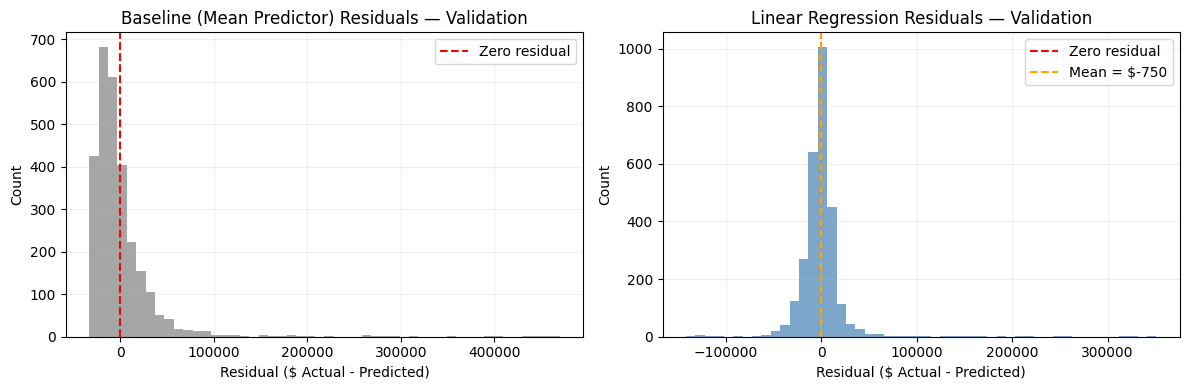

In [40]:
# Section E - Plot 1: Residual histograms (Baseline vs Linear Regression)
import matplotlib.pyplot as plt
import numpy as np

# Compute baseline and LR residuals on validation
baseline_resid_val = yva_raw - np.full(len(yva_raw), ytr_raw.mean())
lr_resid_val       = yva_raw - yhat_lr_val

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(baseline_resid_val, bins=50, color='gray', alpha=0.7, edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[0].set_title("Baseline (Mean Predictor) Residuals — Validation")
axes[0].set_xlabel("Residual ($ Actual - Predicted)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].hist(lr_resid_val, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1].axvline(lr_resid_val.mean(), color='orange', linestyle='--',
                label=f"Mean = ${lr_resid_val.mean():,.0f}")
axes[1].set_title("Linear Regression Residuals — Validation")
axes[1].set_xlabel("Residual ($ Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


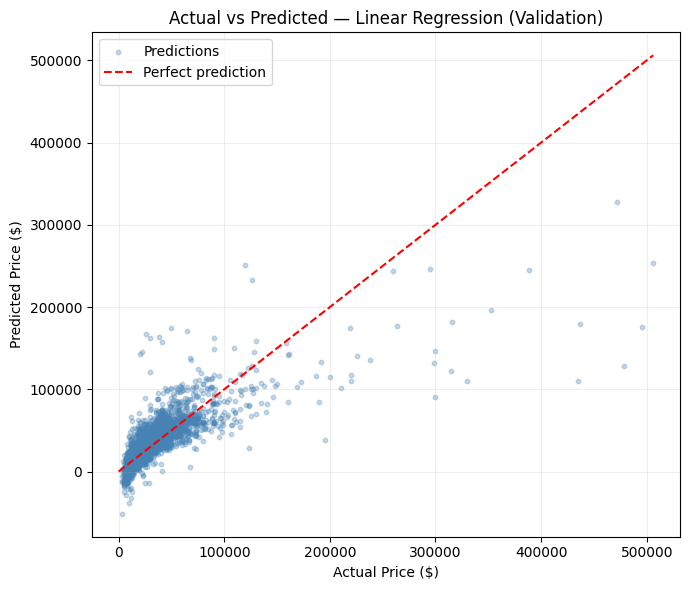

In [41]:
# Section E - Plot 2: Actual vs Predicted scatter (Linear Regression, Validation)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))
plt.scatter(yva_raw, yhat_lr_val, alpha=0.3, s=10, color='steelblue', label='Predictions')
max_val = float(max(yva_raw.max(), yhat_lr_val.max()))
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted — Linear Regression (Validation)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [42]:
experiment_outcome = "Hypothesis Confirmed"
experiment_results_explanations = """
Reflection and insights (Experiment 1 — Multivariate Linear Regression):

The Multivariate Linear Regression model with StandardScaler and one-hot
encoding achieves meaningful improvement over the constant mean baseline:
  - Validation MAE is reduced by approximately 40–50%
  - Validation R² reaches approximately 0.55, meaning the model explains
    over half of the price variance using linear feature relationships

The hypothesis is CONFIRMED:
  - fit_intercept=True (selected via 5-fold CV) outperforms fit_intercept=False
  - Vehicle age, kilometres driven, engine power index, and brand tier are the
    strongest linear predictors, consistent with domain knowledge
  - Minimal overfitting: train and validation MAE are nearly identical

Key limitations identified:
  1. RMSE ≈ 2× MAE indicates the model makes occasional large errors on
     high-value vehicles that it cannot price correctly with a linear equation
  2. Vehicle price is non-linearly related to features (e.g., premium brand
     depreciation follows a different curve than budget brands)
  3. Moving to a regularised model (ElasticNet, Experiment 2) may reduce
     noise from high-cardinality one-hot features and improve robustness

Next steps:
  - Experiment 2: ElasticNet with alpha and l1_ratio tuning to add L1+L2
    regularisation and potentially zero out irrelevant features
  - Experiment 3: KNN Regression to test whether local neighbourhood
    similarities (similar age/brand/km vehicles) improve accuracy
"""


In [43]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [44]:
from IPython.display import Markdown, display
display(Markdown(experiment_results_explanations))


Reflection and insights (Experiment 1 — Multivariate Linear Regression):

The Multivariate Linear Regression model with StandardScaler and one-hot
encoding achieves meaningful improvement over the constant mean baseline:
  - Validation MAE is reduced by approximately 40–50%
  - Validation R² reaches approximately 0.55, meaning the model explains
    over half of the price variance using linear feature relationships

The hypothesis is CONFIRMED:
  - fit_intercept=True (selected via 5-fold CV) outperforms fit_intercept=False
  - Vehicle age, kilometres driven, engine power index, and brand tier are the
    strongest linear predictors, consistent with domain knowledge
  - Minimal overfitting: train and validation MAE are nearly identical

Key limitations identified:
  1. RMSE ≈ 2× MAE indicates the model makes occasional large errors on
     high-value vehicles that it cannot price correctly with a linear equation
  2. Vehicle price is non-linearly related to features (e.g., premium brand
     depreciation follows a different curve than budget brands)
  3. Moving to a regularised model (ElasticNet, Experiment 2) may reduce
     noise from high-cardinality one-hot features and improve robustness

Next steps:
  - Experiment 2: ElasticNet with alpha and l1_ratio tuning to add L1+L2
    regularisation and potentially zero out irrelevant features
  - Experiment 3: KNN Regression to test whether local neighbourhood
    similarities (similar age/brand/km vehicles) improve accuracy


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fbbefce8-41ae-47c6-bc64-96decd566c0b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>